Dataset Loaded Successfully!

First 5 Rows:
   road_id      road_name       road_type  length_km  lanes  speed_limit_kmh  \
0  RD-0001  Jl. Segment 1  Jalan Kolektor        4.3      4               60   
1  RD-0002  Jl. Segment 2    Jalan Arteri        4.3      4               80   
2  RD-0003  Jl. Segment 3     Jalan Lokal        1.8      2               40   
3  RD-0004  Jl. Segment 4  Jalan Kolektor        1.8      4               60   
4  RD-0005  Jl. Segment 5       Jalan Tol       22.7      4               80   

   capacity_vehicles_per_hour  has_bus_lane  has_bike_lane surface_condition  \
0                        5384             0              0             Cukup   
1                        6132             0              0              Baik   
2                         978             0              0             Cukup   
3                        4160             0              1       Rusak Berat   
4                        6600             1              0              Bai

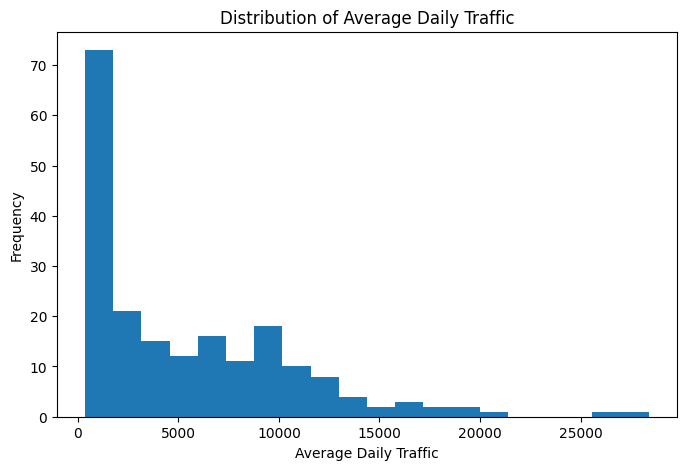

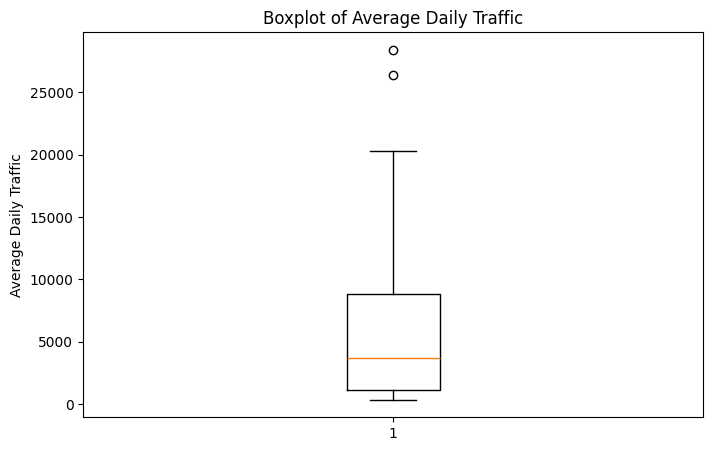

Average Traffic by Road Type:
road_type
Jalan Arteri         8849.448276
Jalan Kolektor       4558.227273
Jalan Lingkungan     1069.065217
Jalan Lokal          1116.121212
Jalan Tol           11589.520833
Name: avg_daily_traffic, dtype: float64



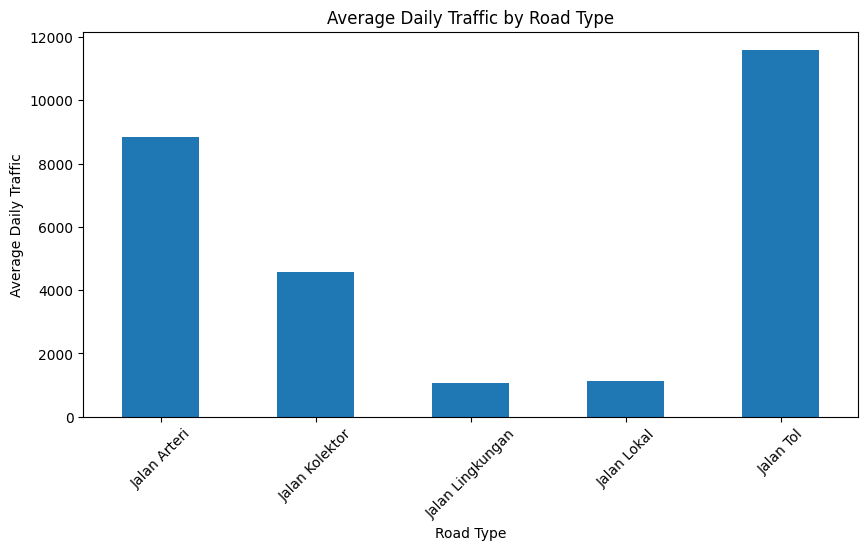

Average Traffic by District:
district
Slipi            10560.800000
Cibubur           8047.900000
Sunter            7357.714286
Senen             7272.357143
Kemang            7181.800000
Kelapa Gading     6314.666667
Bekasi            6313.000000
Menteng           6023.125000
Mangga Dua        5919.555556
Sudirman          5430.333333
Cakung            5148.166667
Senayan           5130.125000
Depok             5098.538462
Tangerang         4744.200000
Cawang            4647.900000
Blok M            4588.666667
Pluit             3972.500000
Grogol            3889.875000
Kuningan          3086.666667
PIK               2558.062500
Name: avg_daily_traffic, dtype: float64



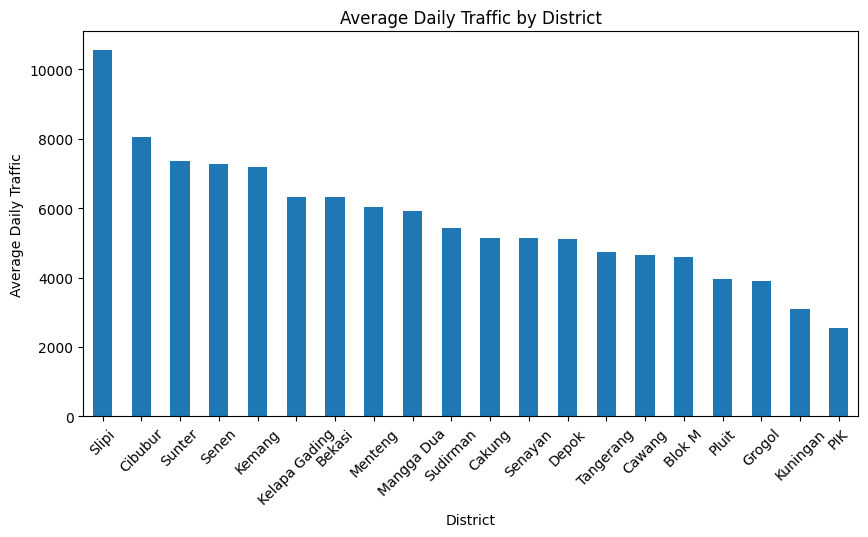

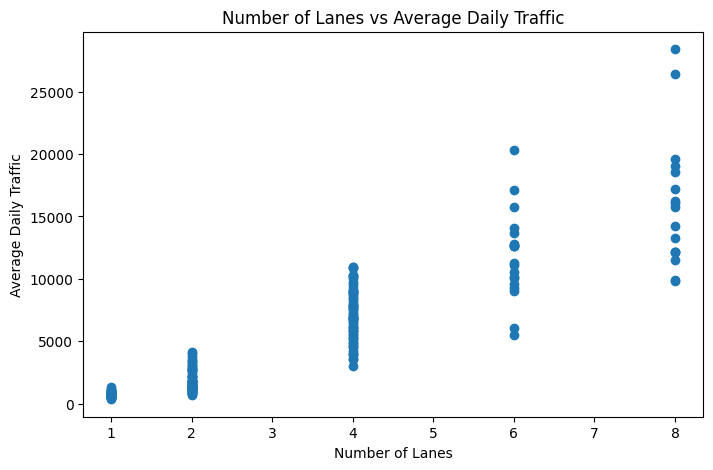

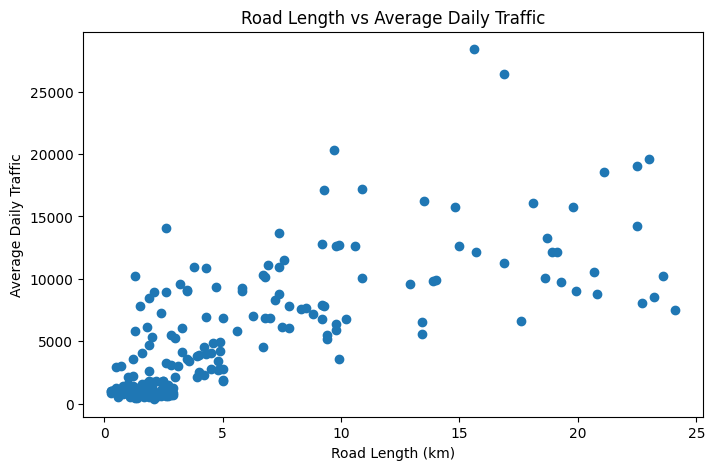

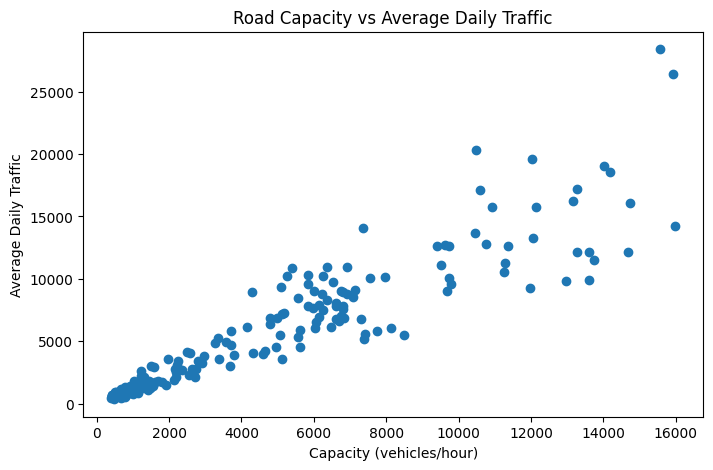

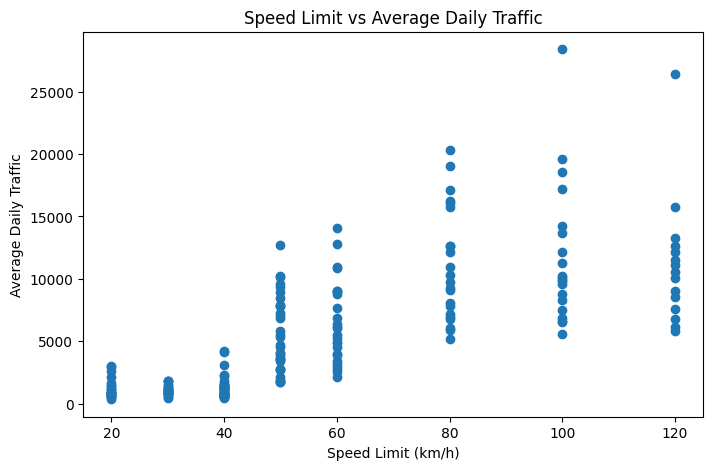

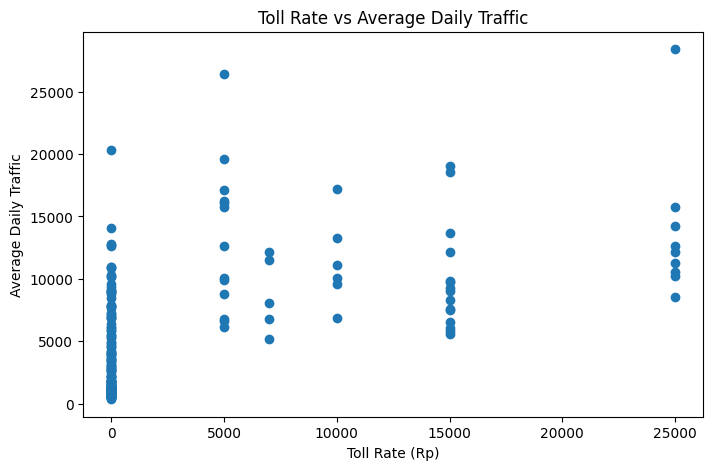

Correlation Matrix:
                            length_km     lanes  speed_limit_kmh  \
length_km                    1.000000  0.743290         0.800769   
lanes                        0.743290  1.000000         0.779259   
speed_limit_kmh              0.800769  0.779259         1.000000   
capacity_vehicles_per_hour   0.794835  0.972050         0.827924   
has_bus_lane                 0.528194  0.570439         0.458482   
has_bike_lane               -0.373309 -0.326214        -0.375806   
latitude_start               0.062111  0.109049         0.001068   
longitude_start             -0.139298 -0.079620        -0.112335   
latitude_end                 0.053255  0.103832        -0.011218   
longitude_end               -0.140968 -0.077213        -0.118027   
toll_rate_rp                 0.750671  0.596186         0.721284   
avg_daily_traffic            0.727531  0.902945         0.744962   

                            capacity_vehicles_per_hour  has_bus_lane  \
length_km              

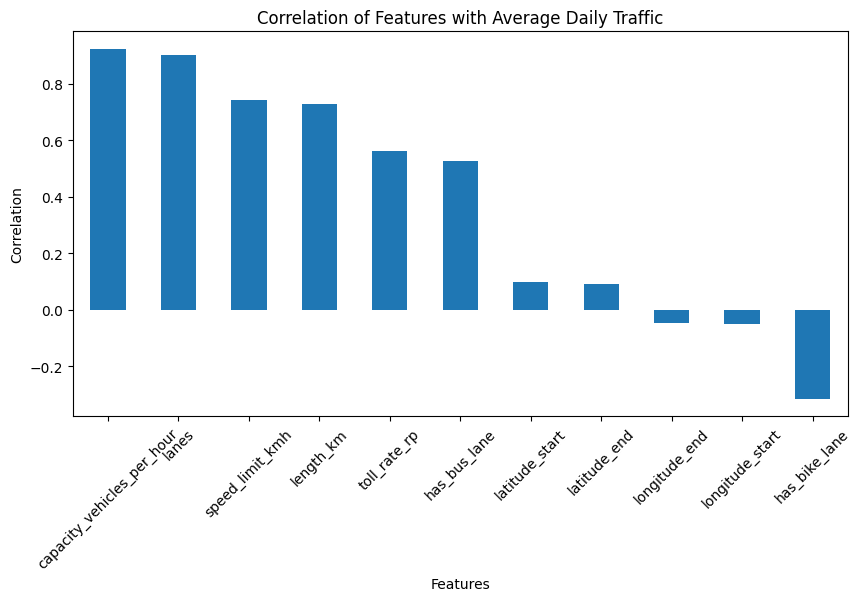

Number of Outliers in Average Daily Traffic:
2

FINAL EDA SUMMARY
Number of Samples: 200
Number of Features/Columns: 18
Missing Values: 0
Duplicate Rows: 0
Target Variable: avg_daily_traffic


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/content/road_network.csv")

print("Dataset Loaded Successfully!")
print()


print("First 5 Rows:")
print(df.head())
print()


print("Last 5 Rows:")
print(df.tail())
print()


print("Dataset Shape:")
print(df.shape)

print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])
print()



print("Column Names:")
print(df.columns.tolist())
print()


print("Dataset Information:")
df.info()
print()

print("Statistical Summary:")
print(df.describe())
print()


print("Missing Values:")
print(df.isnull().sum())
print()


print("Number of Duplicate Rows:")
print(df.duplicated().sum())
print()


print("Number of Unique Values in Each Column:")
print(df.nunique())
print()


print("Data Types:")
print(df.dtypes)
print()


numerical_columns = df.select_dtypes(
    include=np.number
).columns

print("Numerical Columns:")
print(numerical_columns.tolist())
print()

categorical_columns = df.select_dtypes(
    include="object"
).columns

print("Categorical Columns:")
print(categorical_columns.tolist())
print()


plt.figure(figsize=(8, 5))

plt.hist(df["avg_daily_traffic"], bins=20)

plt.title("Distribution of Average Daily Traffic")
plt.xlabel("Average Daily Traffic")
plt.ylabel("Frequency")

plt.show()


plt.figure(figsize=(8, 5))

plt.boxplot(df["avg_daily_traffic"])

plt.title("Boxplot of Average Daily Traffic")
plt.ylabel("Average Daily Traffic")

plt.show()


road_type_traffic = df.groupby(
    "road_type"
)["avg_daily_traffic"].mean()

print("Average Traffic by Road Type:")
print(road_type_traffic)
print()


plt.figure(figsize=(10, 5))

road_type_traffic.plot(kind="bar")

plt.title("Average Daily Traffic by Road Type")
plt.xlabel("Road Type")
plt.ylabel("Average Daily Traffic")

plt.xticks(rotation=45)

plt.show()

district_traffic = df.groupby(
    "district"
)["avg_daily_traffic"].mean().sort_values(
    ascending=False
)

print("Average Traffic by District:")
print(district_traffic)
print()


plt.figure(figsize=(10, 5))

district_traffic.plot(kind="bar")

plt.title("Average Daily Traffic by District")
plt.xlabel("District")
plt.ylabel("Average Daily Traffic")

plt.xticks(rotation=45)

plt.show()

plt.figure(figsize=(8, 5))

plt.scatter(
    df["lanes"],
    df["avg_daily_traffic"]
)

plt.title("Number of Lanes vs Average Daily Traffic")
plt.xlabel("Number of Lanes")
plt.ylabel("Average Daily Traffic")

plt.show()


plt.figure(figsize=(8, 5))

plt.scatter(
    df["length_km"],
    df["avg_daily_traffic"]
)

plt.title("Road Length vs Average Daily Traffic")
plt.xlabel("Road Length (km)")
plt.ylabel("Average Daily Traffic")

plt.show()

plt.figure(figsize=(8, 5))

plt.scatter(
    df["capacity_vehicles_per_hour"],
    df["avg_daily_traffic"]
)

plt.title("Road Capacity vs Average Daily Traffic")
plt.xlabel("Capacity (vehicles/hour)")
plt.ylabel("Average Daily Traffic")

plt.show()


plt.figure(figsize=(8, 5))

plt.scatter(
    df["speed_limit_kmh"],
    df["avg_daily_traffic"]
)

plt.title("Speed Limit vs Average Daily Traffic")
plt.xlabel("Speed Limit (km/h)")
plt.ylabel("Average Daily Traffic")

plt.show()


plt.figure(figsize=(8, 5))

plt.scatter(
    df["toll_rate_rp"],
    df["avg_daily_traffic"]
)

plt.title("Toll Rate vs Average Daily Traffic")
plt.xlabel("Toll Rate (Rp)")
plt.ylabel("Average Daily Traffic")

plt.show()


numeric_df = df.select_dtypes(
    include=np.number
)

correlation = numeric_df.corr()

print("Correlation Matrix:")
print(correlation)
print()


target_correlation = correlation[
    "avg_daily_traffic"
].sort_values(
    ascending=False
)

print("Correlation with Average Daily Traffic:")
print(target_correlation)
print()

target_correlation.drop(
    "avg_daily_traffic"
).plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title(
    "Correlation of Features with Average Daily Traffic"
)

plt.xlabel("Features")
plt.ylabel("Correlation")

plt.xticks(rotation=45)

plt.show()


Q1 = df["avg_daily_traffic"].quantile(0.25)

Q3 = df["avg_daily_traffic"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR

upper_limit = Q3 + 1.5 * IQR

outliers = df[
    (df["avg_daily_traffic"] < lower_limit) |
    (df["avg_daily_traffic"] > upper_limit)
]

print("Number of Outliers in Average Daily Traffic:")
print(len(outliers))
print()

print("=============================================")
print("FINAL EDA SUMMARY")
print("=============================================")

print("Number of Samples:", df.shape[0])
print("Number of Features/Columns:", df.shape[1])

print(
    "Missing Values:",
    df.isnull().sum().sum()
)

print(
    "Duplicate Rows:",
    df.duplicated().sum()
)

print(
    "Target Variable: avg_daily_traffic"
)

print("=============================================")